In [1]:
import scvelo as scv
import scanpy as sc
from multiprocessing import Pool
import anndata as ad
import numpy as np
import pandas as pd
from matplotlib import rcParams

In [2]:
import mudata as mu

In [3]:
scv.settings.figdir = "/data/projects/2021/MicrobialMetabolites/single-cell-sorted-cd8/results/prj_honda_15062026/publication_figures/tumor"


In [4]:
adata = ad.read_h5ad("/data/projects/2021/MicrobialMetabolites/single-cell-sorted-cd8/results/40_gex_surface_prot/002_annotate_adata.h5ad")

In [5]:
adata_paga = ad.read_h5ad("mdata_gex_12022026_paga.h5ad")

In [6]:
adata

AnnData object with n_obs × n_vars = 72592 × 17581
    obs: 'adata_name', 'condition', 'batch_id', 'sample_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'rna_leiden', 'rna_leiden_05', 'gex03', 'group4', 'cell_annotation_05'
    var: 'gene_ids', 'feature_types', 'mito', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'n_cells'
    uns: 'cell_annotation_05_colors', 'gex03', 'gex03_colors', 'group4_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'rna_leiden', 'rna_leiden_05', 'rna_leiden_05_colors', 'rna_leiden_colors', '

In [7]:
adata_paga.obs["cell_annotation_05"] = adata_paga.obs_names.map(
    adata.obs["cell_annotation_05"]
)

In [8]:
adata = adata_paga

In [9]:
adata = adata[~adata.obs_names.duplicated(), :]

In [10]:
import os
import glob
import scvelo as scv
import scanpy as sc

def read_scvelo_2021_looms():
    loom_dir = "/data/projects/2021/MicrobialMetabolites/single-cell-sorted-cd8/results/trajectory_inference/loom"
    
    # find all loom files starting with 2021
    loom_files = sorted(
        glob.glob(os.path.join(loom_dir, "2021*.loom"))
    )
    
    print(f"Found {len(loom_files)} loom files.")
    
    adatas = []
    
    for file in loom_files:
        print(f"Reading {os.path.basename(file)}")
        
        adata = scv.read_loom(file)
        adata.var_names_make_unique()
        
        # store filename (without extension) as metadata
        sample_name = os.path.basename(file).replace(".loom", "")
        adata.obs["sample_id"] = sample_name
        
        adatas.append(adata)
    
    # concatenate all
    adata_combined = sc.concat(adatas, join="outer", label="batch", keys=[a.obs["sample_id"][0] for a in adatas])
    
    return adata_combined


In [11]:
adata_velocity = read_scvelo_2021_looms()

Found 8 loom files.
Reading 2021_10mix-ICI1.loom
Reading 2021_10mix-ICI2.loom
Reading 2021_11mix-ICI1.loom
Reading 2021_11mix-ICI2.loom
Reading 2021_GF-ICI1-plus.loom
Reading 2021_GF-ICI1.loom
Reading 2021_GF-ICI2-plus.loom
Reading 2021_GF-ICI2.loom


In [12]:
adata_scvelo = adata_velocity

In [13]:
adata_scvelo

AnnData object with n_obs × n_vars = 72592 × 32285
    obs: 'sample_id', 'batch'
    layers: 'matrix', 'ambiguous', 'spliced', 'unspliced'

In [14]:
adata.obs_names

Index(['10mix-ICI1_AAACCTGAGAGCCTAG-1', '10mix-ICI1_AAACCTGAGATGTGGC-1',
       '10mix-ICI1_AAACCTGAGGCTCTTA-1', '10mix-ICI1_AAACCTGAGGGCACTA-1',
       '10mix-ICI1_AAACCTGAGGGCTTGA-1', '10mix-ICI1_AAACCTGAGGTTACCT-1',
       '10mix-ICI1_AAACCTGCAACCGCCA-1', '10mix-ICI1_AAACCTGCACTTCTGC-1',
       '10mix-ICI1_AAACCTGCAGCGTAAG-1', '10mix-ICI1_AAACCTGCAGTATGCT-1',
       ...
       'GF-ICI2-plus_TTTGTCAGTTCGCTAA-1', 'GF-ICI2-plus_TTTGTCATCAATAAGG-1',
       'GF-ICI2-plus_TTTGTCATCACGCATA-1', 'GF-ICI2-plus_TTTGTCATCATGGTCA-1',
       'GF-ICI2-plus_TTTGTCATCCAGAGGA-1', 'GF-ICI2-plus_TTTGTCATCCCTTGCA-1',
       'GF-ICI2-plus_TTTGTCATCGTTGCCT-1', 'GF-ICI2-plus_TTTGTCATCTAACTGG-1',
       'GF-ICI2-plus_TTTGTCATCTCTGTCG-1', 'GF-ICI2-plus_TTTGTCATCTGTTGAG-1'],
      dtype='object', length=63948)

In [15]:
import re

# Step 1: extract clean barcode
barcodes = (
    adata_scvelo.obs_names
    .str.split(":").str[1]      # take part after :
    .str.replace("x", "", regex=False)  # remove trailing x
)

# Step 2: clean sample names
samples = (
    adata_scvelo.obs["sample_id"]
    .str.replace("2021_", "", regex=False)
)

# Step 3: build matching obs_names
new_names = samples + "_" + barcodes + "-1"

adata_scvelo.obs_names = new_names


In [16]:
adata_scvelo.obs

,sample_id,batch
10mix-ICI1_AAAGATGGTGATGCCC-1,2021_10mix-ICI1,2021_10mix-ICI1
10mix-ICI1_AAACCTGAGGGCACTA-1,2021_10mix-ICI1,2021_10mix-ICI1
10mix-ICI1_AAACGGGAGAGCTGCA-1,2021_10mix-ICI1,2021_10mix-ICI1
10mix-ICI1_AAAGATGCAGTAGAGC-1,2021_10mix-ICI1,2021_10mix-ICI1
10mix-ICI1_AAACCTGCAGTTCCCT-1,2021_10mix-ICI1,2021_10mix-ICI1
...,...,...
GF-ICI2_TTTGCGCGTCATACTG-1,2021_GF-ICI2,2021_GF-ICI2
GF-ICI2_TTTGGTTAGACAGGCT-1,2021_GF-ICI2,2021_GF-ICI2
GF-ICI2_TTTGGTTTCTTGACGA-1,2021_GF-ICI2,2021_GF-ICI2
GF-ICI2_TTTGTCATCTGACCTC-1,2021_GF-ICI2,2021_GF-ICI2


In [17]:
adata.obs_names

Index(['10mix-ICI1_AAACCTGAGAGCCTAG-1', '10mix-ICI1_AAACCTGAGATGTGGC-1',
       '10mix-ICI1_AAACCTGAGGCTCTTA-1', '10mix-ICI1_AAACCTGAGGGCACTA-1',
       '10mix-ICI1_AAACCTGAGGGCTTGA-1', '10mix-ICI1_AAACCTGAGGTTACCT-1',
       '10mix-ICI1_AAACCTGCAACCGCCA-1', '10mix-ICI1_AAACCTGCACTTCTGC-1',
       '10mix-ICI1_AAACCTGCAGCGTAAG-1', '10mix-ICI1_AAACCTGCAGTATGCT-1',
       ...
       'GF-ICI2-plus_TTTGTCAGTTCGCTAA-1', 'GF-ICI2-plus_TTTGTCATCAATAAGG-1',
       'GF-ICI2-plus_TTTGTCATCACGCATA-1', 'GF-ICI2-plus_TTTGTCATCATGGTCA-1',
       'GF-ICI2-plus_TTTGTCATCCAGAGGA-1', 'GF-ICI2-plus_TTTGTCATCCCTTGCA-1',
       'GF-ICI2-plus_TTTGTCATCGTTGCCT-1', 'GF-ICI2-plus_TTTGTCATCTAACTGG-1',
       'GF-ICI2-plus_TTTGTCATCTCTGTCG-1', 'GF-ICI2-plus_TTTGTCATCTGTTGAG-1'],
      dtype='object', length=63948)

In [18]:
len(set(adata.obs_names)), len(set(adata_scvelo.obs_names)), len(
    set(adata.obs_names) & set(adata_scvelo.obs_names)
)

(63948, 72592, 63948)

In [19]:
adata_scvelo = scv.utils.merge(adata_scvelo, adata)

In [20]:
scv.pp.filter_and_normalize(adata_scvelo)

Normalized count data: X, spliced, unspliced.
Logarithmized X.


/home/kvalem/.conda/envs/scvelo_03_2024/lib/python3.10/site-packages/scvelo/preprocessing/utils.py:705: DeprecationWarning: `log1p` is deprecated since scVelo v0.3.0 and will be removed in a future version. Please use `log1p` from `scanpy.pp` instead.
  log1p(adata)


In [21]:
scv.pp.moments(adata_scvelo, n_pcs=30, n_neighbors=30, mode='distances')

computing neighbors
    finished (0:00:44) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing moments based on distances
    finished (0:00:16) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)


In [22]:
scv.tl.recover_dynamics(adata_scvelo)

recovering dynamics (using 1/144 cores)


  0%|          | 0/61 [00:00<?, ?gene/s]

    finished (0:07:33) --> added 
    'fit_pars', fitted parameters for splicing dynamics (adata.var)


In [23]:
scv.tl.latent_time(adata_scvelo)

computing velocities


/home/kvalem/.conda/envs/scvelo_03_2024/lib/python3.10/site-packages/scvelo/tools/optimization.py:184: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  gamma[i] = np.linalg.pinv(A.T.dot(A)).dot(A.T.dot(y[:, i]))


    finished (0:01:34) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 1/144 cores)


  0%|          | 0/63948 [00:00<?, ?cells/s]

    finished (0:00:49) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing terminal states
    identified 8 regions of root cells and 1 region of end points .
    finished (0:00:28) --> added
    'root_cells', root cells of Markov diffusion process (adata.obs)
    'end_points', end points of Markov diffusion process (adata.obs)
computing latent time using root_cells as prior
    finished (0:01:54) --> added 
    'latent_time', shared time (adata.obs)


In [24]:
scv.tl.velocity(adata_scvelo)

computing velocities


/home/kvalem/.conda/envs/scvelo_03_2024/lib/python3.10/site-packages/scvelo/tools/optimization.py:184: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  gamma[i] = np.linalg.pinv(A.T.dot(A)).dot(A.T.dot(y[:, i]))


    finished (0:02:01) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)


/home/kvalem/.conda/envs/scvelo_03_2024/lib/python3.10/site-packages/scvelo/plotting/utils.py:63: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/kvalem/.conda/envs/scvelo_03_2024/lib/python3.10/site-packages/scvelo/plotting/utils.py:63: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/kvalem/.conda/envs/scvelo_03_2024/lib/python3.10/site-packages/scvelo/plotting/utils.py:63: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/kvalem/.conda/envs/scvelo_03_2024/lib

saving figure to file /data/projects/2021/MicrobialMetabolites/single-cell-sorted-cd8/results/prj_honda_15062026/publication_figures/tumor/scvelo_latent_time_tumor.png


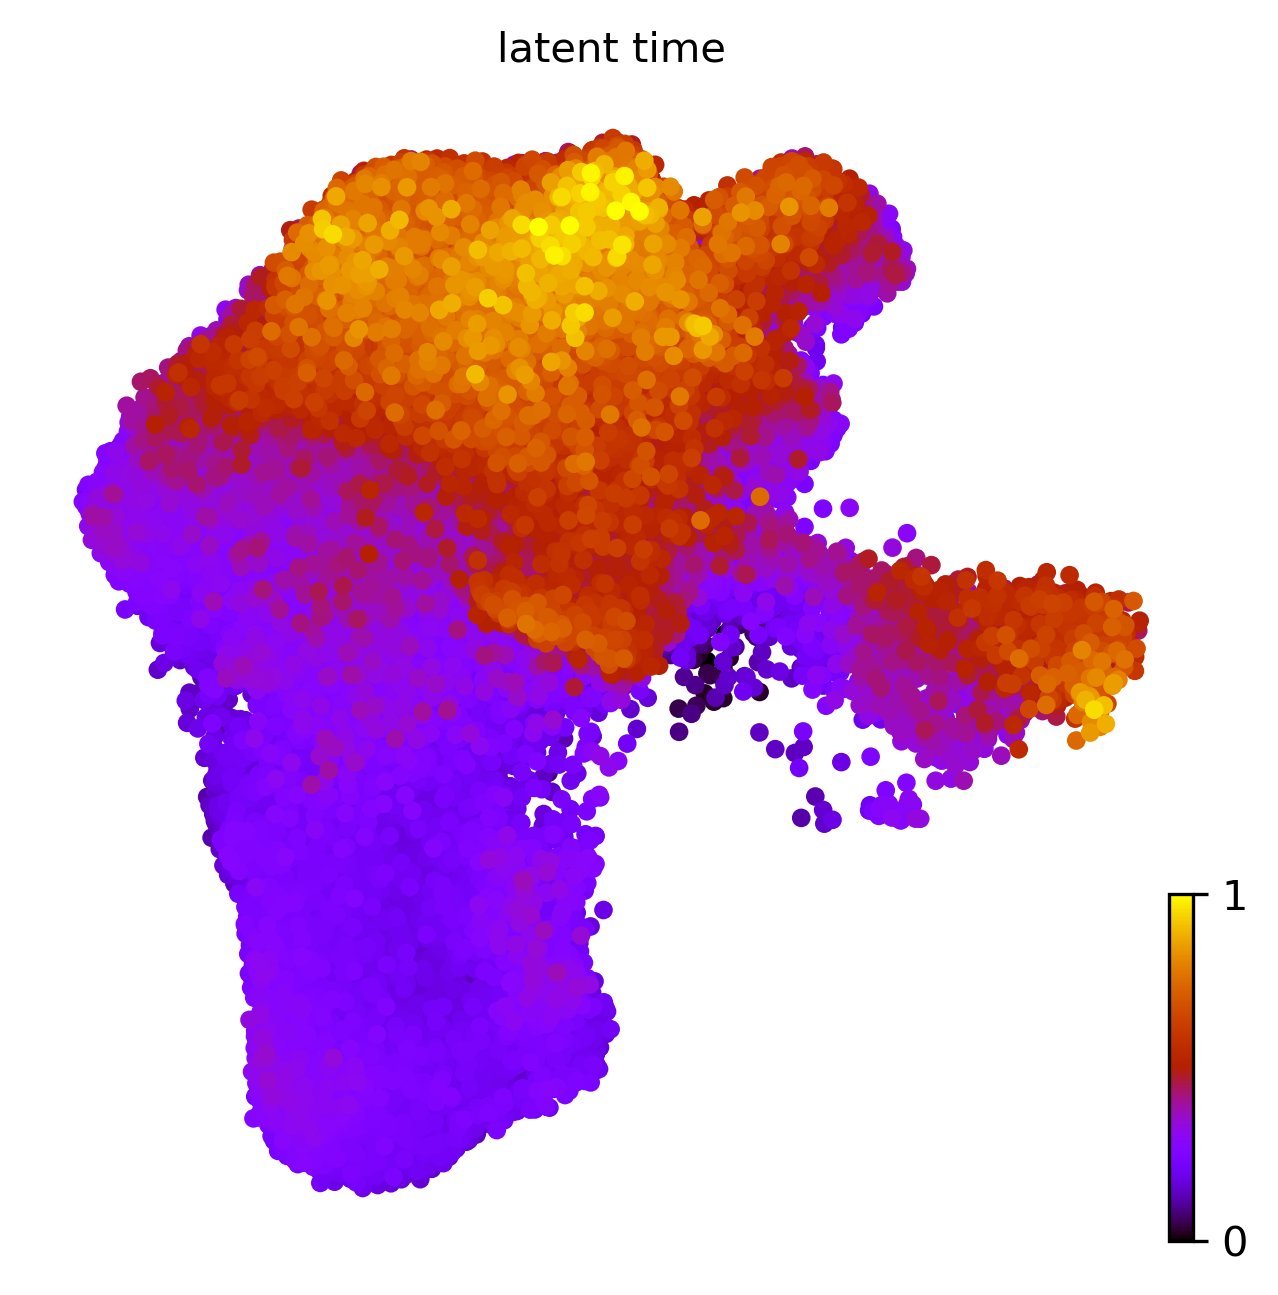

In [25]:
scv.pl.scatter(adata_scvelo, color='latent_time', color_map='gnuplot', size=80, save = "latent_time_tumor.png" , dpi =300,figsize= (5,5) )


In [26]:
scv.tl.velocity(adata_scvelo, mode='dynamical')
scv.tl.velocity_graph(adata_scvelo)

computing velocities
    finished (0:00:17) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 1/144 cores)


  0%|          | 0/63948 [00:00<?, ?cells/s]

    finished (0:00:37) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)


/home/kvalem/.conda/envs/scvelo_03_2024/lib/python3.10/site-packages/scvelo/plotting/utils.py:63: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/kvalem/.conda/envs/scvelo_03_2024/lib/python3.10/site-packages/scvelo/plotting/utils.py:63: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/kvalem/.conda/envs/scvelo_03_2024/lib/python3.10/site-packages/scvelo/plotting/utils.py:63: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/kvalem/.conda/envs/scvelo_03_2024/lib

saving figure to file /data/projects/2021/MicrobialMetabolites/single-cell-sorted-cd8/results/prj_honda_15062026/publication_figures/tumor/scvelo_dynamic_velocity_tumor.png


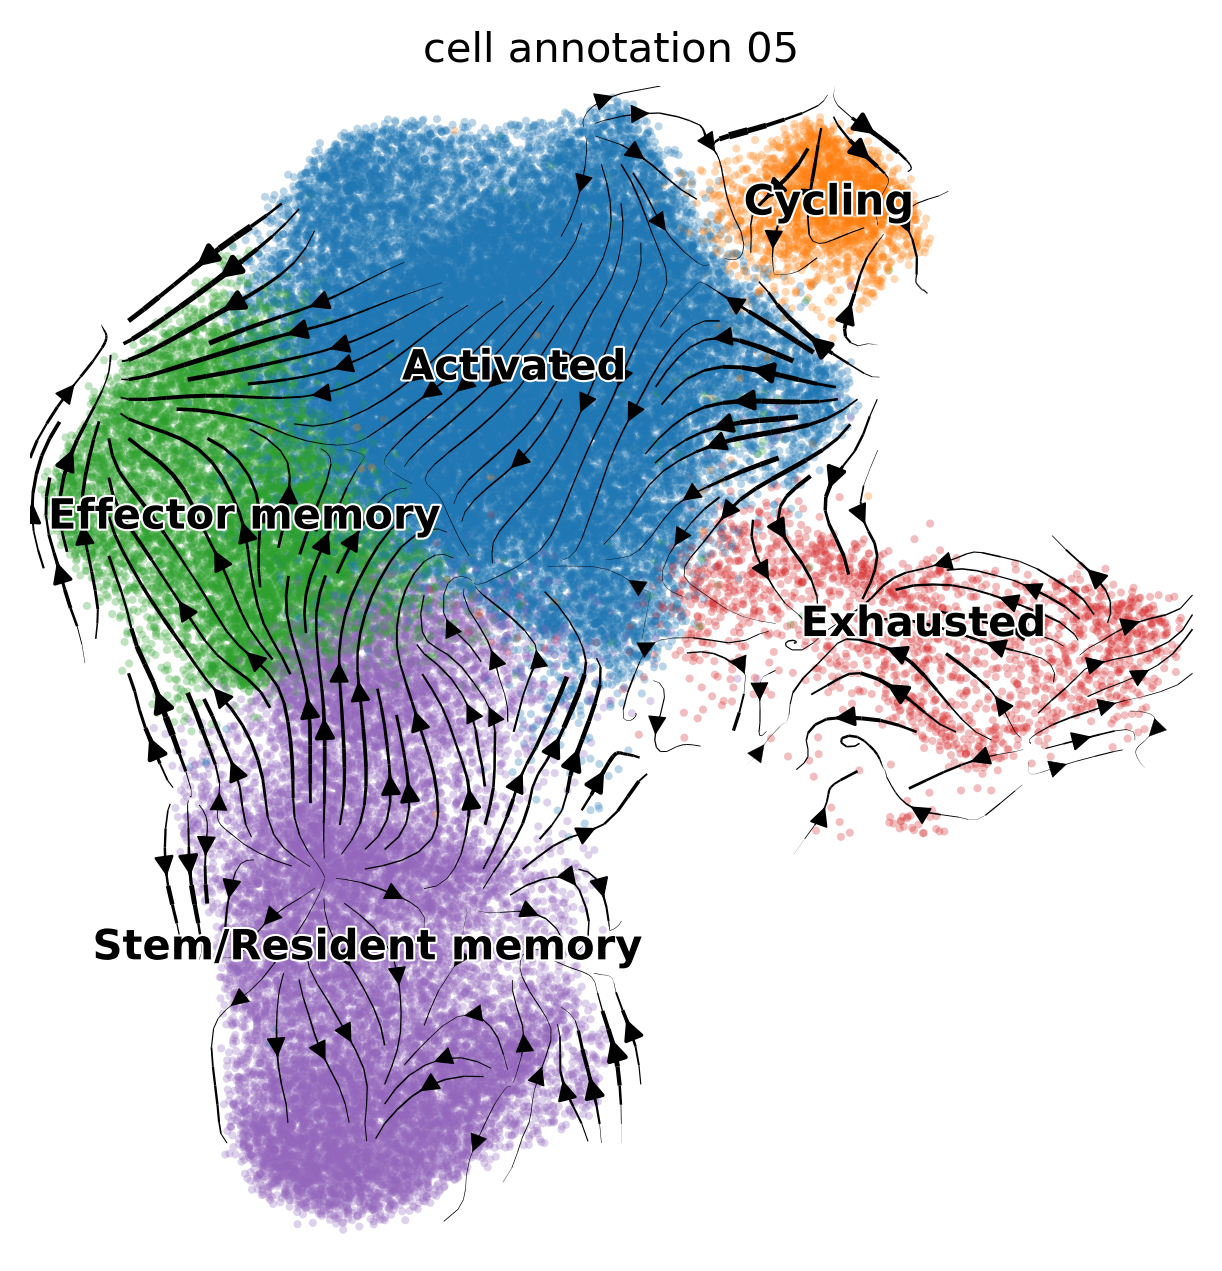

In [32]:
scv.pl.velocity_embedding_stream(adata_scvelo, basis='umap',  color="cell_annotation_05", save=  "dynamic_velocity_tumor.png", dpi=300,figsize= (5,5))


In [33]:
#scv.tl.velocity_graph(adata_scvelo)

computing velocity graph (using 1/96 cores)


  0%|          | 0/63948 [00:00<?, ?cells/s]

    finished (0:00:43) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)


In [27]:
#adata_scvelo

AnnData object with n_obs × n_vars = 63948 × 17581
    obs: 'sample_id', 'batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'adata_name', 'condition', 'batch_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'rna_leiden', 'rna_leiden_05', 'gex03', 'is_outlier_counts', 'is_outlier_genes', 'is_outlier_top_20', 'is_outlier_mito', 'is_outlier', 'mt_outlier', 'gex04', 'dpt_pseudotime', 'cell_annotation_05', 'n_counts', 'velocity_self_transition', 'root_cells', 'end_points', 'velocity_pseudotime', 'latent_time'
    var: 'gene_ids', 'feature_types', 'genome', 'pattern', 'read', 'sequence', 'mito', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 

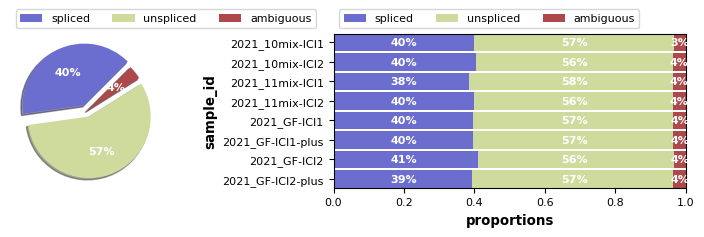

In [36]:
scv.pl.proportions(adata_scvelo, groupby="sample_id")

In [37]:
#sc.set_figure_params(figsize=(10, 10))
#rcParams["axes.grid"] = False


/home/kvalem/.conda/envs/scvelo_03_2024/lib/python3.10/site-packages/scanpy/_settings.py:450: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  IPython.display.set_matplotlib_formats(*ipython_format)


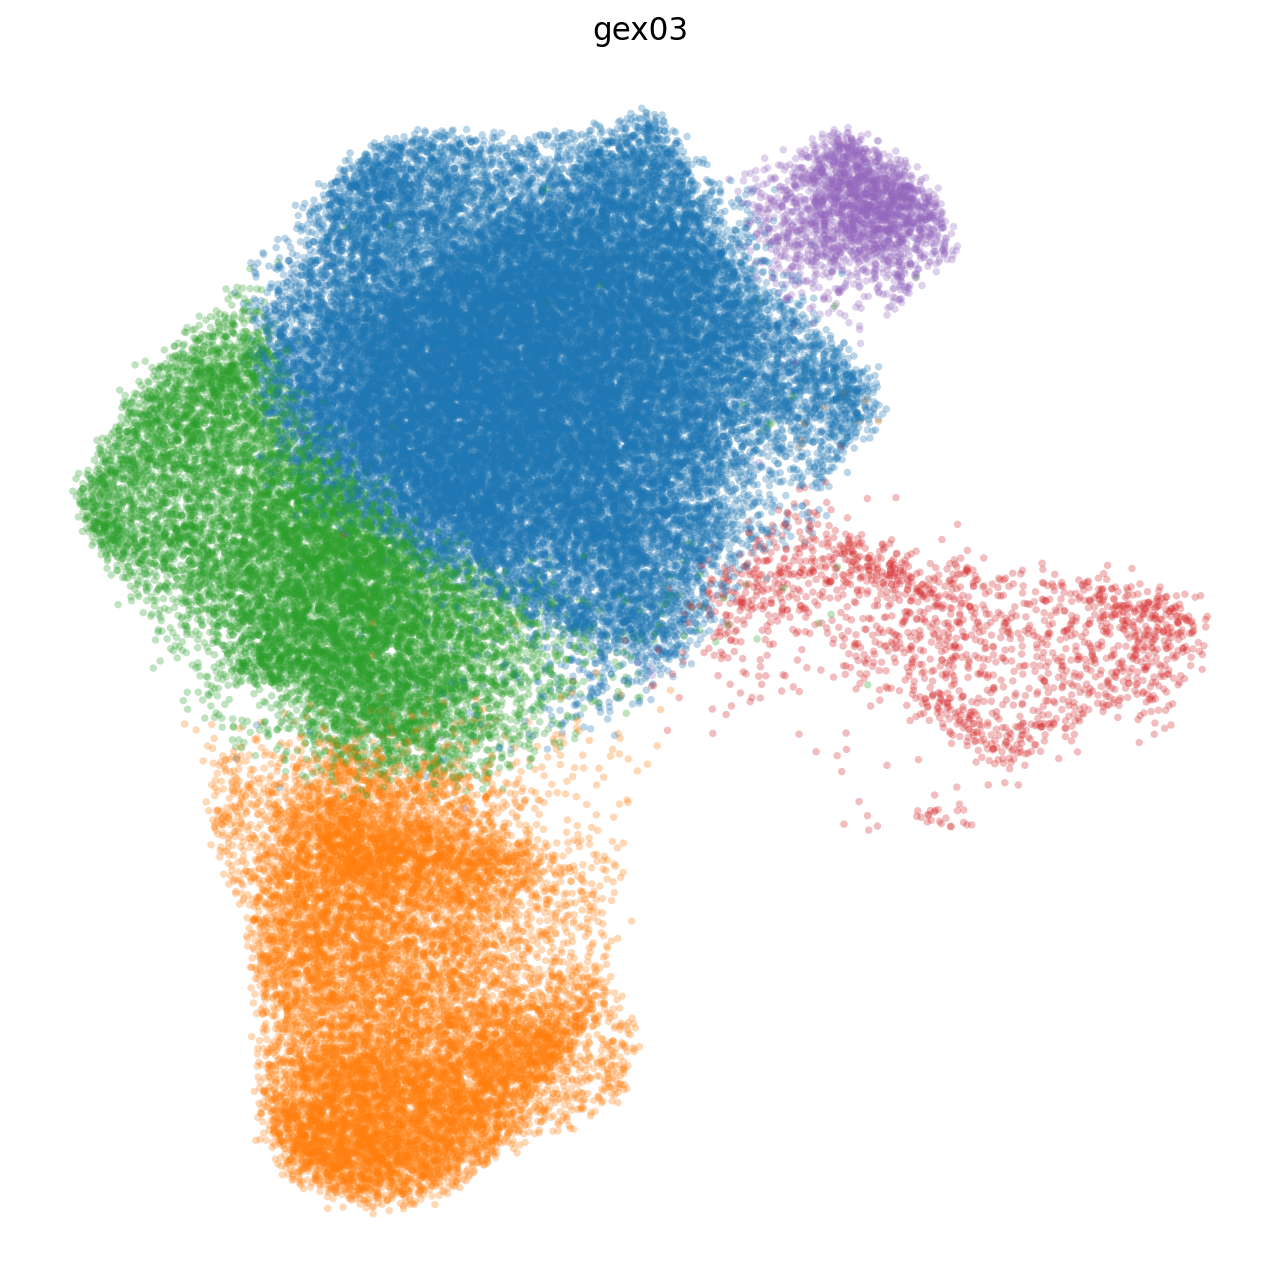

In [72]:
#ax = sc.pl.embedding(
#    adata,
#    basis="X_umap",
#    color="gex03",
#    show=False,
#    legend_loc="None",
#    size=45,
#    alpha=0.3,frameon=False
#)

In [73]:
#scv.pl.velocity_embedding_stream(
#    adata_scvelo,
#    basis="X_umap",
#    color="gex03",
#    #     arrow_color="white",
#    legend_loc="right margin",
#    ax=ax,
#    alpha=0,
#)

/home/kvalem/.conda/envs/scvelo_03_2024/lib/python3.10/site-packages/scvelo/plotting/utils.py:63: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/kvalem/.conda/envs/scvelo_03_2024/lib/python3.10/site-packages/scvelo/plotting/utils.py:63: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/kvalem/.conda/envs/scvelo_03_2024/lib/python3.10/site-packages/scvelo/plotting/utils.py:63: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/kvalem/.conda/envs/scvelo_03_2024/lib

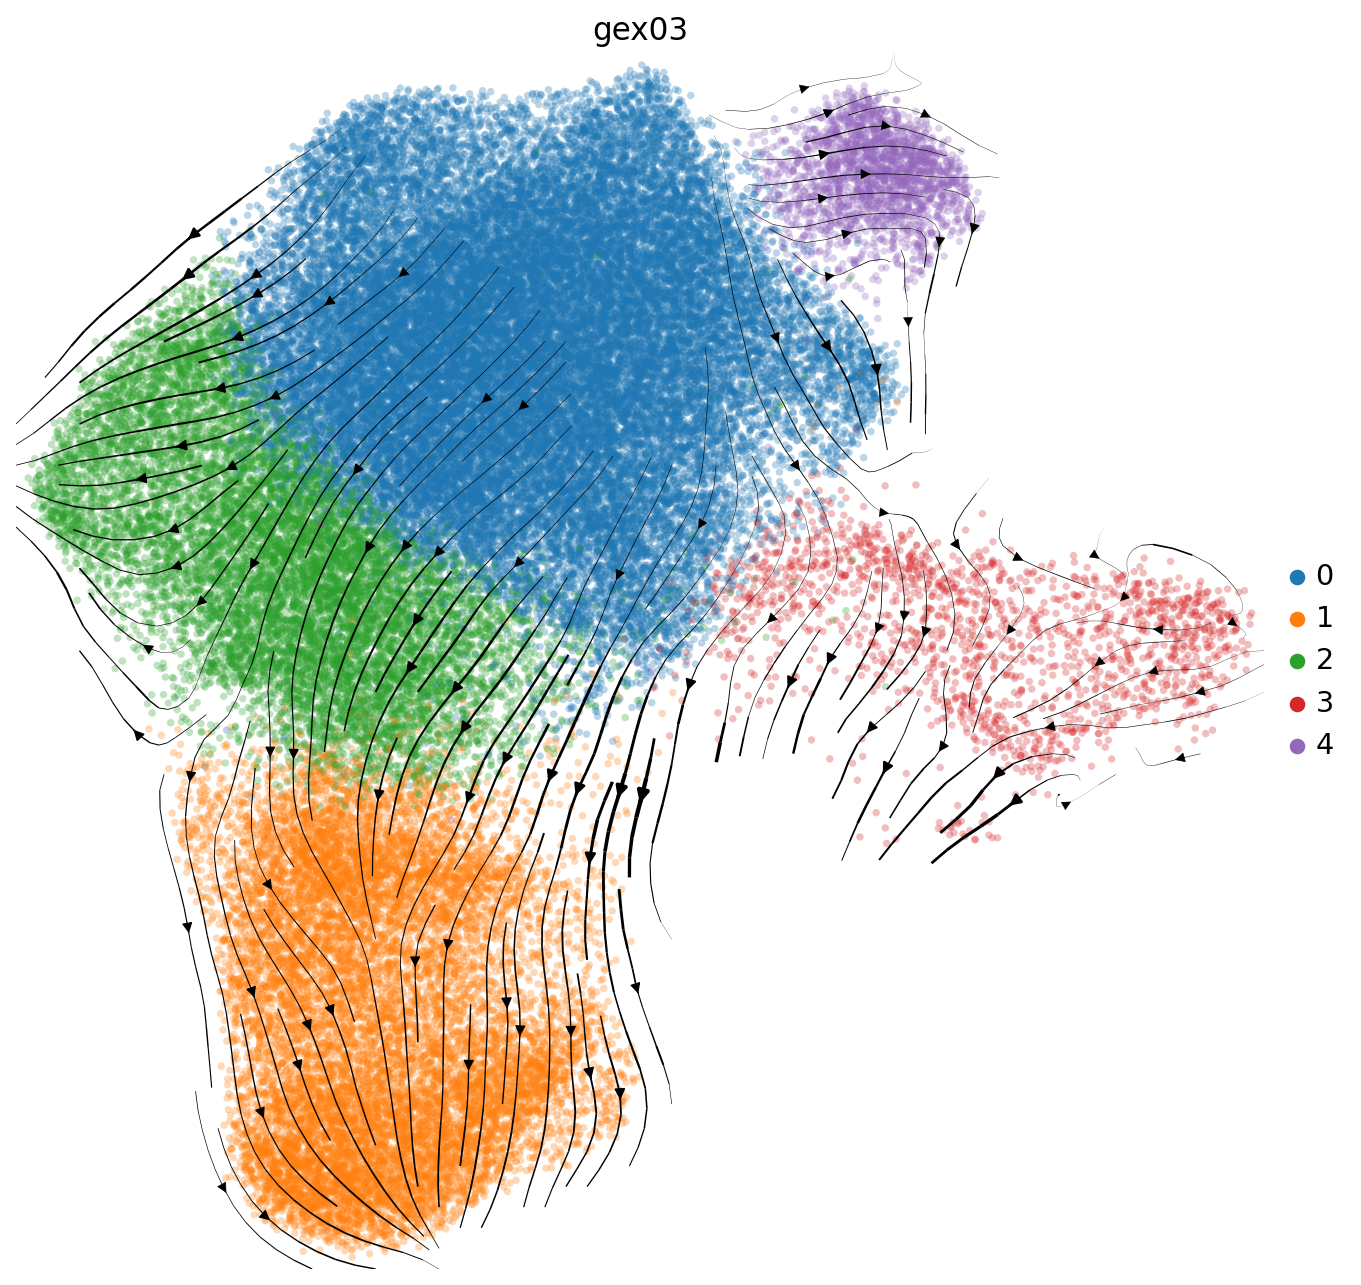

In [74]:
#ax.get_figure()